# Assumption Junction — GAM: Telco Customer Churn

This notebook evaluates a **Logistic Generalized Additive Model (GAM)** for predicting customer churn. The goal is to assess whether a GAM provides useful predictive performance while remaining interpretable, and to identify assumptions or limitations that should be considered before acting on the model's explanations.


In [ ]:
!pip -q install pygam


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from pygam import LogisticGAM, s, f


## 1. Dataset Loading and Cleaning

The dataset contains historical telecom customer records. Each row represents one customer. The target variable is `Churn`, indicating whether the customer left the company.


In [ ]:
uploaded = files.upload()


Saving archive.zip to archive (1).zip


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Original shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


`TotalCharges` should be numeric, but it is initially stored as an object because some rows contain blank strings. We inspect and then convert this column to numeric.


In [ ]:
blank_total_charges = df[df["TotalCharges"].str.strip() == ""]
print("Rows with blank TotalCharges:", len(blank_total_charges))
blank_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

df = df.dropna(subset=["TotalCharges"]).copy()
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Cleaned shape:", df.shape)
print(df["Churn"].value_counts())


### Variable Roles

- **Target:** `Churn` (0 = stayed, 1 = churned)
- **Identifier excluded from predictors:** `customerID`
- **Continuous predictors modeled with smooth GAM terms `s()`:** `tenure`, `MonthlyCharges`, `TotalCharges`
- **Categorical/indicator predictors modeled with factor terms `f()`:** all remaining predictors, including `SeniorCitizen`

This is not feature selection: the baseline GAM uses all 19 meaningful predictors. The distinction determines **how** each predictor enters the GAM.


In [ ]:
pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})


,Column,Data Type
customerID,customerID,object
gender,gender,object
SeniorCitizen,SeniorCitizen,int64
Partner,Partner,object
Dependents,Dependents,object
tenure,tenure,int64
PhoneService,PhoneService,object
MultipleLines,MultipleLines,object
InternetService,InternetService,object
OnlineSecurity,OnlineSecurity,object


## 2. EDA Relevant to GAM Assumptions

The purpose of this EDA is to understand the churn outcome, examine whether the continuous predictors show non-constant/nonlinear patterns with churn, and identify potential redundancy among predictors that could complicate interpretation.


In [ ]:
print("Churn proportions:")
print(df["Churn"].value_counts(normalize=True))

print("\nMean continuous predictors by churn:")
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean())

print("\nCorrelation among continuous predictors:")
print(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(3))

print("\nDuplicate customer IDs:", df["customerID"].duplicated().sum())


Churn proportions:
Churn
0    0.734215
1    0.265785

Mean continuous predictors by churn:
          tenure  MonthlyCharges  TotalCharges
Churn                                         
0      37.650010       61.307408   2555.344141
1      17.979133       74.441332   1531.796094

Correlation among continuous predictors:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.247         0.826
MonthlyCharges   0.247           1.000         0.651
TotalCharges     0.826           0.651         1.000

Duplicate customer IDs: 0


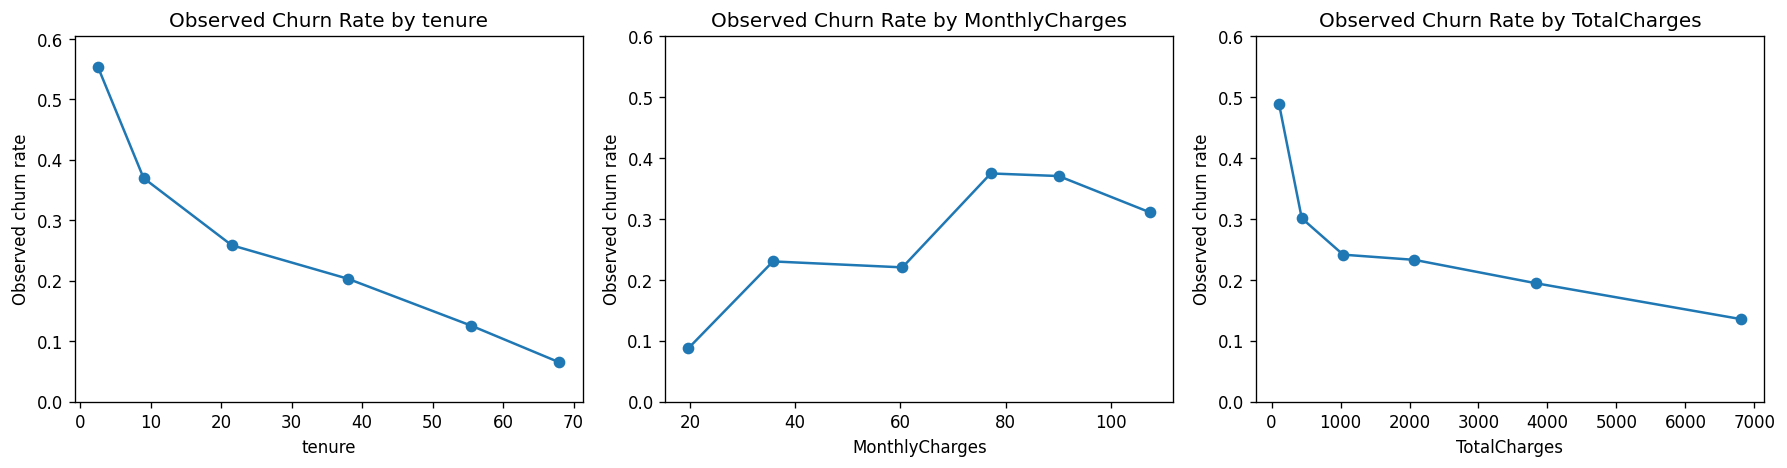

In [ ]:
# Bin each continuous variable only for EDA visualization.
# These bins are NOT used to fit the GAM.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    bins = pd.qcut(df[col], q=6, duplicates="drop")
    churn_rate = df.groupby(bins, observed=True)["Churn"].mean()
    midpoints = [(interval.left + interval.right) / 2 for interval in churn_rate.index]

    ax.plot(midpoints, churn_rate.values, marker="o")
    ax.set_xlabel(col)
    ax.set_ylabel("Observed churn rate")
    ax.set_title(f"Observed Churn Rate by {col}")

plt.tight_layout()
plt.show()


### EDA Interpretation

- **Tenure:** observed churn decreases strongly as tenure increases. The change is not simply a single constant step across the range, making a flexible smooth term reasonable.
- **MonthlyCharges:** churn varies across charge levels rather than following one obviously constant linear pattern, supporting a flexible smooth term.
- **TotalCharges:** observed churn generally decreases as total charges increase, but this variable is strongly related to tenure.
- **Predictor redundancy concern:** `tenure` and `TotalCharges` have a correlation of approximately **0.826**. Their separate GAM effects therefore need cautious interpretation.
- **Independence evidence available in this dataset:** there are **0 duplicate customer IDs**, so each row is a distinct recorded customer. This supports, but does not prove, the independence assumption.


## 3. Prepare the Predictors and Train/Test Split

The model is trained on 80% of the cleaned historical customers and evaluated on the remaining 20%. `stratify=y` preserves the churn proportion in both splits.


In [ ]:
X_df = df.drop(columns=["customerID", "Churn"]).copy()
y = df["Churn"].values

# Convert text categories to numeric codes required by pyGAM.
# They are still treated as categorical because the model uses f() terms.
categorical_cols = X_df.select_dtypes(include="object").columns

for col in categorical_cols:
    X_df[col] = X_df[col].astype("category").cat.codes

X = X_df.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])
print("Number of predictors:", X_train.shape[1])


Training observations: 5625
Testing observations: 1407
Number of predictors: 19


## 4. Fit the Logistic GAM

The GAM uses:

- `s()` for the three continuous predictors, allowing flexible nonlinear relationships.
- `f()` for categorical/indicator predictors, allowing category-specific effects.

All 19 predictors are included in the baseline model.


In [ ]:
# Predictor positions after removing customerID and Churn:
# 0 gender
# 1 SeniorCitizen
# 2 Partner
# 3 Dependents
# 4 tenure
# 5 PhoneService
# 6 MultipleLines
# 7 InternetService
# 8 OnlineSecurity
# 9 OnlineBackup
# 10 DeviceProtection
# 11 TechSupport
# 12 StreamingTV
# 13 StreamingMovies
# 14 Contract
# 15 PaperlessBilling
# 16 PaymentMethod
# 17 MonthlyCharges
# 18 TotalCharges

gam = LogisticGAM(
    f(0) + f(1) + f(2) + f(3) +
    s(4) +
    f(5) + f(6) + f(7) + f(8) + f(9) +
    f(10) + f(11) + f(12) + f(13) +
    f(14) + f(15) + f(16) +
    s(17) + s(18)
)

gam.fit(X_train, y_train)
print("GAM fitted successfully!")


GAM fitted successfully!


## 5. Model Performance

Performance is measured on the held-out test customers that were not used to fit the GAM.

- **Accuracy** measures the proportion of test customers classified correctly.
- **ROC-AUC** measures how well the model ranks actual churners above non-churners across possible classification thresholds.


In [ ]:
y_prob = gam.predict_proba(X_test)
y_pred = gam.predict(X_test)

auc = roc_auc_score(y_test, y_prob)
accuracy = accuracy_score(y_test, y_pred)

print("Test ROC-AUC:", round(auc, 3))
print("Test Accuracy:", round(accuracy, 3))


Test ROC-AUC: 0.841
Test Accuracy: 0.796


On the held-out test set of **1,407 customers**, the Logistic GAM achieved:

- **ROC-AUC = 0.841**
- **Accuracy = 0.796**

This indicates reasonably strong discrimination between churners and non-churners in the held-out historical data.


## 6. Smooth-Effect Interpretation

The following plots show the learned contribution of each continuous predictor to the GAM's underlying churn score. Values above zero push the model more toward churn relative to the model baseline; values below zero push it more away from churn. These y-axis values are **not churn probabilities**.


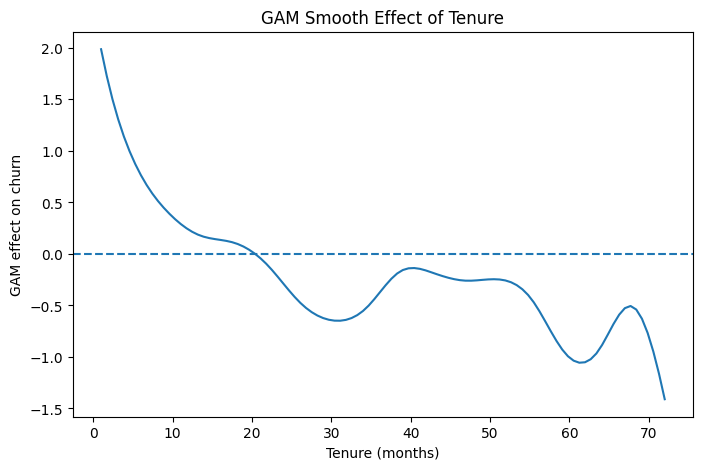

In [ ]:
plt.figure(figsize=(8, 5))

XX = gam.generate_X_grid(term=4)

plt.plot(
    XX[:, 4],
    gam.partial_dependence(term=4, X=XX)
)

plt.xlabel("Tenure (months)")
plt.ylabel("GAM effect on churn")
plt.title("GAM Smooth Effect of Tenure")
plt.axhline(0, linestyle="--")
plt.show()

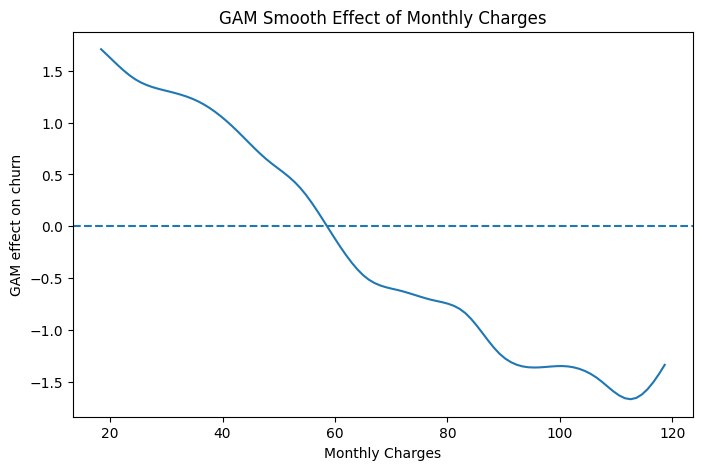

In [ ]:
plt.figure(figsize=(8, 5))

XX = gam.generate_X_grid(term=17)

plt.plot(
    XX[:, 17],
    gam.partial_dependence(term=17, X=XX)
)

plt.xlabel("Monthly Charges")
plt.ylabel("GAM effect on churn")
plt.title("GAM Smooth Effect of Monthly Charges")
plt.axhline(0, linestyle="--")
plt.show()

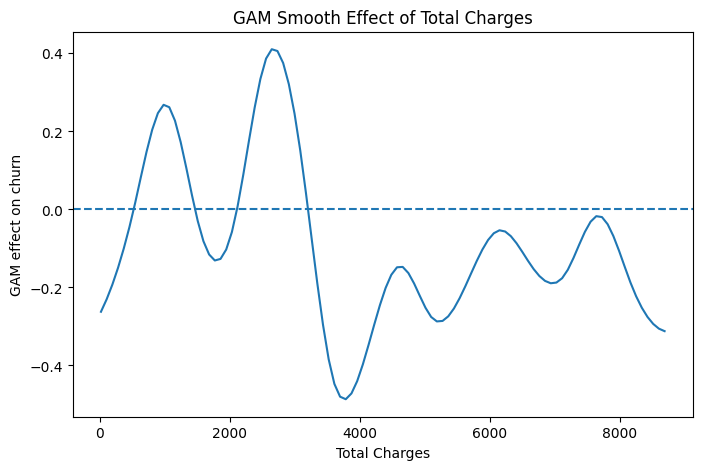

In [ ]:
plt.figure(figsize=(8, 5))

XX = gam.generate_X_grid(term=18)

plt.plot(
    XX[:, 18],
    gam.partial_dependence(term=18, X=XX)
)

plt.xlabel("Total Charges")
plt.ylabel("GAM effect on churn")
plt.title("GAM Smooth Effect of Total Charges")
plt.axhline(0, linestyle="--")
plt.show()

### Smooth-Effect Interpretation

- **Tenure:** the learned effect is strongly positive at very low tenure and generally becomes negative as tenure increases. In the fitted model, very new customers therefore contribute more toward a churn prediction, while longer tenure generally contributes away from churn. The curved shape shows why a GAM can be useful instead of forcing one constant linear effect.

- **MonthlyCharges:** the fitted smooth contribution generally declines as monthly charges increase after accounting for the other predictors in the model. This differs from the raw group averages, where churners had higher average monthly charges. That difference is important: a GAM smooth is a **conditional model effect**, not a simple raw correlation, and it should be interpreted cautiously because the model also contains contract, services, tenure, and TotalCharges.

- **TotalCharges:** the fitted effect is noticeably wavy rather than monotonic. Because `TotalCharges` is strongly correlated with `tenure` (about 0.826) and also related to `MonthlyCharges`, its isolated smooth effect is difficult to interpret confidently. This is evidence of a predictor-redundancy concern.

These effects describe associations learned from historical data; they do not establish causation.


## 7. GAM Assumption Checks

| Assumption / concern | Evidence checked in this notebook | Interpretation / concern |
|---|---|---|
| Appropriate outcome/model family | `Churn` is binary and encoded 0/1; a `LogisticGAM` is fit | Appropriate for a binary churn outcome |
| Smooth functional form for continuous predictors | EDA churn-rate plots and fitted smooth-effect plots | Continuous relationships are not forced to be straight lines; the observed/fitted patterns support use of smooth terms |
| Additive structure | Model specification uses separate `s()` and `f()` terms with no interaction terms | The baseline GAM can miss interactions, such as MonthlyCharges having different effects for different contract types |
| Independent observations | One row per customer; duplicate customer IDs = 0 | Supports row-level independence, but unobserved dependence cannot be ruled out from this dataset alone |
| Predictor redundancy / concurvity concern | `corr(tenure, TotalCharges) ≈ 0.826`; TotalCharges smooth is unstable/wavy | Separate effects of tenure and TotalCharges may be difficult to interpret |
| Data quality | Blank `TotalCharges` values were identified, converted to missing, and 11 affected rows were removed | Cleaning is documented; removing observations slightly changes the analysis sample |

These checks provide evidence relevant to the GAM assumptions, but they do not prove that every assumption is perfectly satisfied.


## 8. Limitation

A key limitation of this baseline GAM is its **additive structure**. Although it can learn nonlinear effects for continuous predictors, it does not automatically model interactions between predictors. For example, the effect of monthly charges may differ between month-to-month and two-year contract customers.

A second interpretability concern is the strong relationship between `tenure` and `TotalCharges`. Because these predictors contain overlapping information, their individual smooth effects should not be treated as clean, independent causal effects.

Finally, all relationships are associations learned from historical observational data. The company should not conclude that changing one predictor will necessarily cause churn to change.


## 9. GAM Conclusion

The Logistic GAM provides an interpretable approach to churn prediction because it combines categorical effects with flexible nonlinear smooth effects for continuous predictors.

On the held-out historical test set, the model achieved **ROC-AUC = 0.841** and **accuracy = 0.796**. The smooth plots make the model's learned continuous relationships inspectable, especially the strong nonlinear tenure effect.

Before acting on these explanations, the telecom company should remain cautious about the model's additive structure, possible interactions, predictor redundancy (especially tenure versus TotalCharges), and the fact that the analysis supports association rather than causation.
